# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data

In [ ]:
games_odds = pd.read_csv("data/game_odds.csv")
games_index = pd.read_csv("data/games_index.csv")
games_schedule = pd.read_csv("data/games_schedule.csv")
play_by_play = pd.read_csv("data/play_by_play.csv")
player_boxscores = pd.read_csv("data/player_boxscores.csv")
team_boxscores = pd.read_csv("data/team_boxscores.csv")

In [ ]:
# print("Game Odds:")
# display(games_odds.head())
# print("Games Index:")
# display(games_index.head())
# print("Games Schedule:")
# display(games_schedule.head())
# print("Play-by-Play:")
# display(play_by_play.head())
# print("Player Boxscores:")
# display(player_boxscores.head())
# print("Team Boxscores:")
# display(team_boxscores.head())


Aggregated Player Stats:


,player_id,player_name,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,2,Byron Scott,LAL,87,6.632184,1.494253,1.264368,0.540230,0.183908,0.701149,18.082701,2.045977,4.735632,0.885057,2.287356,1.655172,1.954023,3.080460,1.252874,0.241379
1,3,Grant Long,ATL,59,10.067797,6.271186,1.033898,1.271186,0.338983,1.644068,29.463927,3.169492,7.576271,0.067797,0.372881,3.661017,4.728814,3.288136,4.101695,2.169492
2,3,Grant Long,BOS,49,1.510204,1.795918,0.530612,0.183673,0.020408,0.408163,10.700510,0.571429,1.510204,0.000000,0.061224,0.367347,0.469388,-1.693878,1.244898,0.551020
3,3,Grant Long,DET,110,4.472727,3.481818,0.609091,0.690909,0.163636,0.636364,18.175136,1.645455,3.727273,0.154545,0.481818,1.027273,1.381818,0.700000,2.127273,1.354545
4,3,Grant Long,MEM,66,6.318182,3.500000,2.060606,0.954545,0.181818,1.560606,28.304571,2.484848,5.833333,0.045455,0.257576,1.303030,1.863636,-5.818182,3.030303,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8343,1643133,Lawson Lovering,MEM,2,7.000000,7.500000,1.500000,1.500000,0.500000,1.000000,24.632500,3.000000,5.000000,0.000000,0.000000,1.000000,2.500000,0.500000,4.500000,3.000000
8344,1643141,Jahmyl Telfort,LAC,8,0.125000,0.375000,0.125000,0.125000,0.000000,0.125000,4.004167,0.000000,0.500000,0.000000,0.500000,0.125000,0.500000,-0.875000,0.375000,0.000000
8345,1643158,Andersson Garcia,UTA,5,5.200000,8.400000,2.800000,1.600000,0.800000,1.400000,33.750000,1.800000,5.800000,0.200000,2.600000,1.400000,1.800000,-7.400000,5.000000,3.400000
8346,1643253,Toby Okani,MEM,6,10.000000,3.500000,1.000000,0.666667,0.500000,0.500000,36.181667,4.166667,11.666667,1.500000,5.166667,0.166667,1.333333,-22.833333,2.000000,1.500000


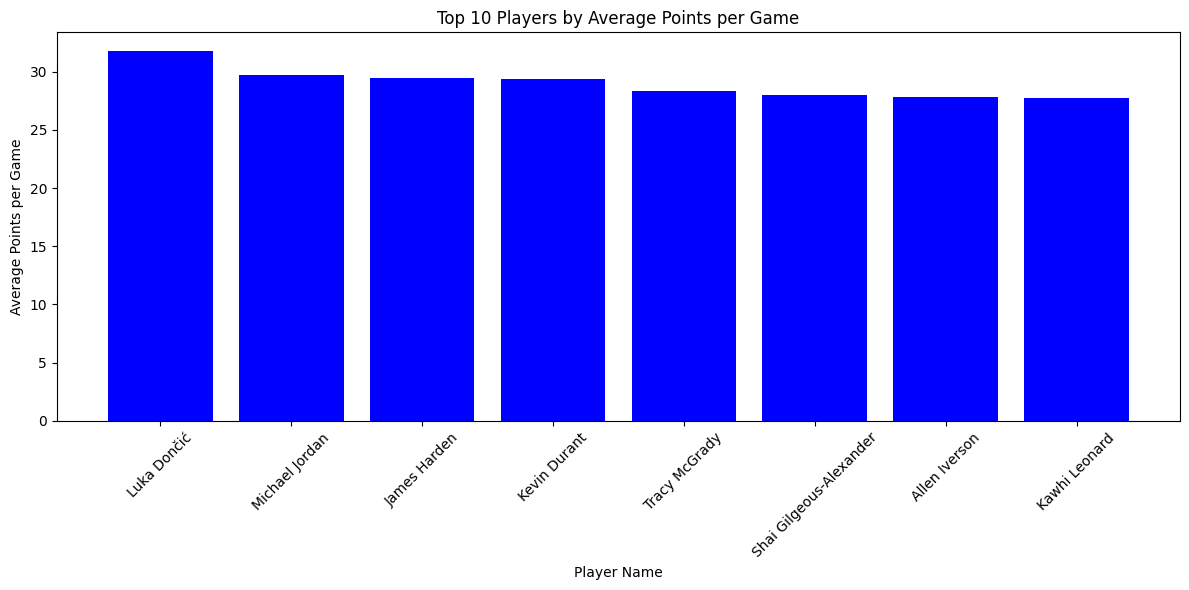

                  player_name     points
7031              Luka Dončić  31.783505
1049           Michael Jordan  29.696078
4507             James Harden  29.434844
3996             Kevin Durant  29.349315
7030              Luka Dončić  28.887712
3999             Kevin Durant  28.469325
1561            Tracy McGrady  28.316129
6911  Shai Gilgeous-Alexander  27.965587
1174            Allen Iverson  27.844388
5110            Kawhi Leonard  27.714286


In [33]:
stat_columns = {
        "pts":   "points",
        "reb":   "rebounds",
        "ast":   "assists",
        "stl":   "steals",
        "blk":   "blocks",
        "tov":   "turnovers",
        "min":   "minutes",
        "fgm":   "Field Goals Made",
        "fga":   "Field Goals Attempted",
        "fg3m":  "Three Pointers Made",
        "fg3a":  "Three Pointers Attempted",
        "ftm":   "Free Throws Made",
        "fta":   "Free Throws Attempted",
        "plus_minus": "impact of player on team performance",
        "dreb":  "defensive rebounds",
        "oreb":  "offensive rebounds",
    }
available = {k: v for k, v in stat_columns.items() if k in player_boxscores.columns}
agg_summary = (
        player_boxscores.groupby(["player_id", "player_name", "team_abbreviation"], as_index=False)
          .agg(
              games=("game_id", "nunique"),
              **{v: (k, "mean") for k, v in available.items()}
          )
    )
print("Aggregated Player Stats:")
display(agg_summary)

# Example: Plotting average points per game for top 10 players
top_players = agg_summary.sort_values("points", ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_players["player_name"], top_players["points"], color='blue')
plt.xlabel("Player Name")
plt.ylabel("Average Points per Game")
plt.title("Top 10 Players by Average Points per Game")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_players[["player_name", "points"]])

In [ ]:
# Teams for Luka Doncic
luka_teams = agg_summary[agg_summary["player_name"] == "Luka Dončić"]["team_abbreviation"].unique()
print(f"Luka Dončić has played for the following teams: {', '.join(luka_teams)}")

Luka Doncic has played for the following teams: 
